In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    ttest_1samp,
    ttest_ind,
    ttest_rel,
    f_oneway,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportions_ztest

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# Generate e-commerce data set

n = 5000

customer_id = np.arange(1, n + 1)

age = np.random.normal(loc=38, scale=12, size=n).astype(int)
age = np.clip(age, 18, 70)

gender = np.random.choice(["Male", "Female"], size=n, p=[0.52, 0.48])

country = np.random.choice(
    ["USA", "India", "UK", "Canada", "Germany"],
    size=n,
    p=[0.45, 0.25, 0.12, 0.10, 0.08]
)

customer_segment = np.random.choice(
    ["New", "Regular", "Premium", "VIP"],
    size=n,
    p=[0.35, 0.40, 0.20, 0.05]
)

campaign = np.random.choice(
    ["Campaign_A", "Campaign_B"],
    size=n,
    p=[0.50, 0.50]
)

visit_frequency = np.random.poisson(lam=6, size=n)
visit_frequency = np.clip(visit_frequency, 1, 25)

discount = np.random.normal(loc=12, scale=6, size=n)
discount = np.clip(discount, 0, 40)

segment_effect = {
    "New": 20,
    "Regular": 45,
    "Premium": 90,
    "VIP": 180
}

campaign_effect = {
    "Campaign_A": 0,
    "Campaign_B": 12
}

base_purchase = []

for i in range(n):
    value = (
        25
        + age[i] * 0.8
        + visit_frequency[i] * 6
        + discount[i] * 1.5
        + segment_effect[customer_segment[i]]
        + campaign_effect[campaign[i]]
        + np.random.normal(0, 35)
    )
    base_purchase.append(value)

purchase_amount = np.array(base_purchase)


purchase_amount = np.exp(np.log(np.maximum(purchase_amount, 5)) + np.random.normal(0, 0.35, n))
purchase_amount = np.round(purchase_amount, 2)

quantity = np.random.poisson(lam=3, size=n)
quantity = np.clip(quantity, 1, 15)


return_probability = 0.05 + (discount / 100) + np.where(customer_segment == "New", 0.04, 0)
returned = np.random.binomial(1, np.clip(return_probability, 0, 0.45))


churn_probability = (
    0.35
    - visit_frequency * 0.015
    - np.log1p(purchase_amount) * 0.025
    + np.where(customer_segment == "New", 0.10, 0)
)
churn_probability = np.clip(churn_probability, 0.02, 0.65)
churned = np.random.binomial(1, churn_probability)

df = pd.DataFrame({
    "CustomerID": customer_id,
    "Age": age,
    "Gender": gender,
    "Country": country,
    "CustomerSegment": customer_segment,
    "Campaign": campaign,
    "VisitFrequency": visit_frequency,
    "Discount": np.round(discount, 2),
    "Quantity": quantity,
    "PurchaseAmount": purchase_amount,
    "Returned": returned,
    "Churned": churned
})

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (5000, 12)
   CustomerID  Age  Gender Country CustomerSegment    Campaign  \
0           1   39    Male     USA             New  Campaign_A   
1           2   24  Female     USA             New  Campaign_A   
2           3   50    Male     USA         Regular  Campaign_A   
3           4   27  Female  Canada             New  Campaign_A   
4           5   42    Male   India         Regular  Campaign_A   

   VisitFrequency  Discount  Quantity  PurchaseAmount  Returned  Churned  
0               5     12.00         1          121.88         0        0  
1               6      0.00         4           47.60         0        0  
2               4     15.74         3          110.48         0        0  
3               5      5.72         2           45.75         0        0  
4               1     15.45         4          136.71         0        0  


In [6]:
# Data Overview and Cleaning

print("\nData Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic description:")
print(df.describe())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Age              5000 non-null   int64  
 2   Gender           5000 non-null   object 
 3   Country          5000 non-null   object 
 4   CustomerSegment  5000 non-null   object 
 5   Campaign         5000 non-null   object 
 6   VisitFrequency   5000 non-null   int32  
 7   Discount         5000 non-null   float64
 8   Quantity         5000 non-null   int32  
 9   PurchaseAmount   5000 non-null   float64
 10  Returned         5000 non-null   int32  
 11  Churned          5000 non-null   int32  
dtypes: float64(2), int32(4), int64(2), object(4)
memory usage: 390.8+ KB
None

Missing values:
CustomerID         0
Age                0
Gender             0
Country            0
CustomerSegment    0
Campaign           0
VisitFrequency 

In [7]:
# Descriptive statistics


numeric_cols = ["Age", "VisitFrequency", "Discount", "Quantity", "PurchaseAmount"]

desc_stats = df[numeric_cols].agg([
    "mean",
    "median",
    "std",
    "var",
    "min",
    "max",
    "skew",
    "kurt"
]).T

desc_stats["range"] = df[numeric_cols].max() - df[numeric_cols].min()
desc_stats["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)

print("\nDescriptive Statistics:")
print(desc_stats)



Descriptive Statistics:
                      mean  median        std          var   min     max  \
Age              37.743600   38.00  11.349768   128.817222  18.0   70.00   
VisitFrequency    5.963800    6.00   2.377061     5.650420   1.0   17.00   
Discount         12.066206   11.87   5.946680    35.362999   0.0   33.20   
Quantity          3.074600    3.00   1.657946     2.748785   1.0   12.00   
PurchaseAmount  175.853940  157.62  88.167124  7773.441782   3.1  770.46   

                    skew      kurt   range       IQR  
Age             0.188973 -0.429362   52.00   16.0000  
VisitFrequency  0.440916  0.240949   16.00    3.0000  
Discount        0.155055 -0.263117   33.20    8.2300  
Quantity        0.744375  0.381831   11.00    2.0000  
PurchaseAmount  1.322292  2.809317  767.36  104.4225  


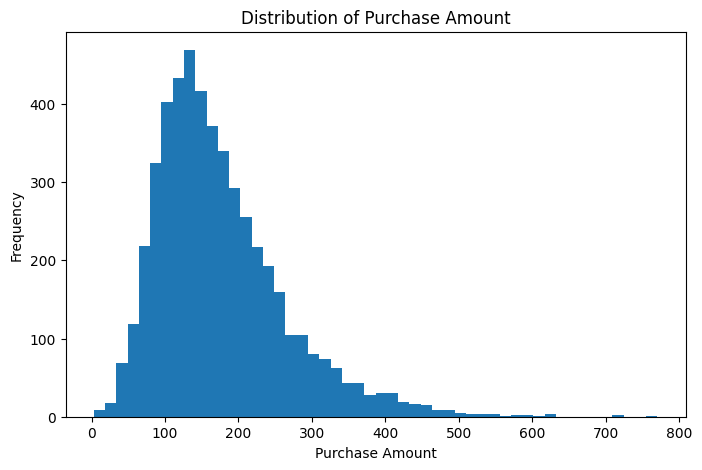

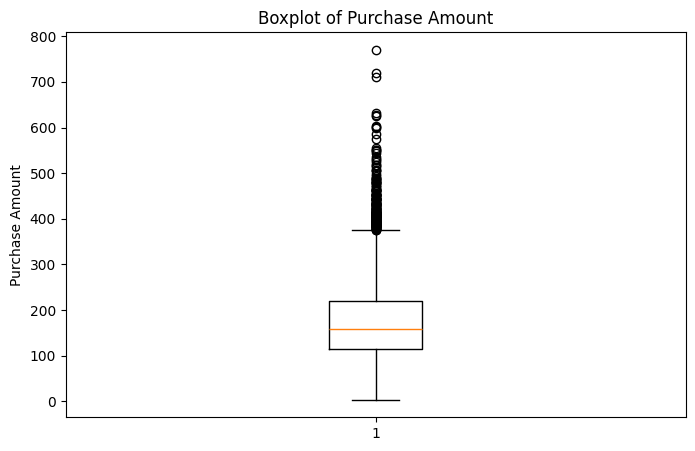

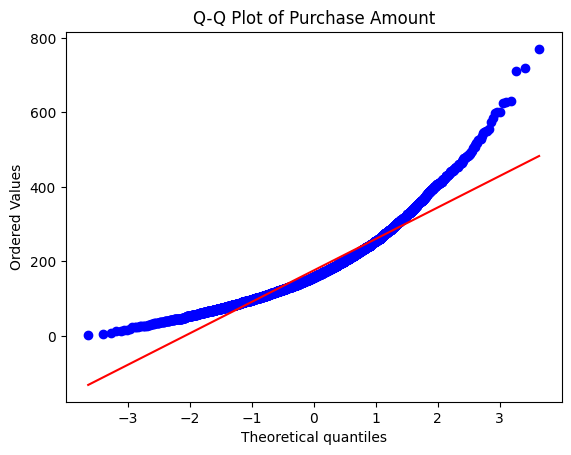

In [11]:
# Distribution analysis


plt.figure(figsize=(8, 5))
plt.hist(df["PurchaseAmount"], bins=50)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df["PurchaseAmount"])
plt.title("Boxplot of Purchase Amount")
plt.ylabel("Purchase Amount")
plt.show()

stats.probplot(df["PurchaseAmount"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Purchase Amount")
plt.show()


In [13]:
# Normality tests


sample_purchase = df["PurchaseAmount"].sample(500, random_state=42)

shapiro_stat, shapiro_p = shapiro(sample_purchase)
normaltest_stat, normaltest_p = normaltest(sample_purchase)

print("\nNormality Tests for Purchase Amount:")
print("Shapiro-Wilk statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p)
print("D'Agostino statistic:", normaltest_stat)
print("D'Agostino p-value:", normaltest_p)

if shapiro_p < 0.05:
    print("Conclusion: PurchaseAmount is not normally distributed.")
else:
    print("Conclusion: PurchaseAmount looks approximately normal.")


Normality Tests for Purchase Amount:
Shapiro-Wilk statistic: 0.8890368840036862
Shapiro-Wilk p-value: 1.6414461406466986e-18
D'Agostino statistic: 191.7212861184538
D'Agostino p-value: 2.33481076853222e-42
Conclusion: PurchaseAmount is not normally distributed.


In [14]:
# Outlier detection using IQR


Q1 = df["PurchaseAmount"].quantile(0.25)
Q3 = df["PurchaseAmount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df["PurchaseAmount"] < lower_bound) |
    (df["PurchaseAmount"] > upper_bound)
]

print("\nIQR Outlier Detection:")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers_iqr))

print("\nTop 10 high-value customers:")
print(df.sort_values("PurchaseAmount", ascending=False).head(10))


IQR Outlier Detection:
Lower bound: -42.066250000000025
Upper bound: 375.62375000000003
Number of outliers: 175

Top 10 high-value customers:
      CustomerID  Age  Gender Country CustomerSegment    Campaign  \
1578        1579   32    Male      UK         Premium  Campaign_B   
4131        4132   46  Female     USA             VIP  Campaign_B   
2364        2365   39    Male   India         Regular  Campaign_A   
4264        4265   42  Female     USA         Premium  Campaign_A   
3077        3078   52    Male     USA             VIP  Campaign_B   
869          870   48  Female     USA             VIP  Campaign_B   
43            44   26    Male     USA         Premium  Campaign_B   
3444        3445   69    Male     USA             VIP  Campaign_B   
3825        3826   48  Female   India             VIP  Campaign_A   
2343        2344   18    Male     USA             VIP  Campaign_A   

      VisitFrequency  Discount  Quantity  PurchaseAmount  Returned  Churned  
1578               

In [15]:
# Z-score and standardization


df["Purchase_Zscore"] = stats.zscore(df["PurchaseAmount"])

z_outliers = df[np.abs(df["Purchase_Zscore"]) > 3]

print("\nZ-score Outlier Detection:")
print("Number of z-score outliers:", len(z_outliers))
print(z_outliers[["CustomerID", "PurchaseAmount", "Purchase_Zscore"]].head())



Z-score Outlier Detection:
Number of z-score outliers: 69
     CustomerID  PurchaseAmount  Purchase_Zscore
43           44          602.35         4.837843
321         322          453.81         3.152920
495         496          484.31         3.498888
525         526          463.25         3.260000
577         578          477.92         3.426405


In [16]:
# Probability and conditional probability


p_spend_100 = np.mean(df["PurchaseAmount"] > 100)
p_returned = np.mean(df["Returned"] == 1)
p_return_given_discount = np.mean(df[df["Discount"] > 20]["Returned"] == 1)
p_churn_premium = np.mean(df[df["CustomerSegment"] == "Premium"]["Churned"] == 1)

print("\nProbability Analysis:")
print("P(PurchaseAmount > 100):", p_spend_100)
print("P(Returned):", p_returned)
print("P(Returned | Discount > 20%):", p_return_given_discount)
print("P(Churned | Premium customer):", p_churn_premium)


Probability Analysis:
P(PurchaseAmount > 100): 0.8274
P(Returned): 0.1888
P(Returned | Discount > 20%): 0.31896551724137934
P(Churned | Premium customer): 0.14575289575289574


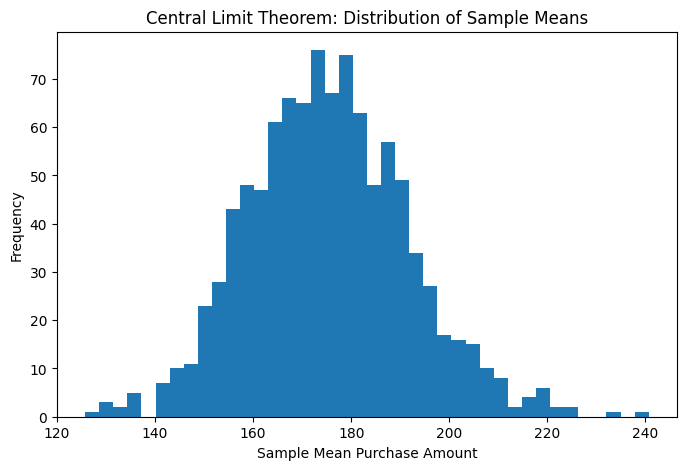


CLT Analysis:
Original mean: 175.85394
Mean of sample means: 175.29926033333334
Standard deviation of sample means: 16.369244631927682


In [17]:
# Central Limit Theorem


sample_means = []

for i in range(1000):
    sample = df["PurchaseAmount"].sample(30, replace=True)
    sample_means.append(sample.mean())

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=40)
plt.title("Central Limit Theorem: Distribution of Sample Means")
plt.xlabel("Sample Mean Purchase Amount")
plt.ylabel("Frequency")
plt.show()

print("\nCLT Analysis:")
print("Original mean:", df["PurchaseAmount"].mean())
print("Mean of sample means:", np.mean(sample_means))
print("Standard deviation of sample means:", np.std(sample_means))


In [18]:
# Confidence interval for average purchase amount


mean_purchase = df["PurchaseAmount"].mean()
std_purchase = df["PurchaseAmount"].std()
n_obs = len(df)

confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = stats.t.ppf(1 - alpha / 2, df=n_obs - 1)
margin_error = t_critical * (std_purchase / np.sqrt(n_obs))

ci_lower = mean_purchase - margin_error
ci_upper = mean_purchase + margin_error

print("\n95% Confidence Interval for Average Purchase Amount:")
print("Mean:", mean_purchase)
print("CI Lower:", ci_lower)
print("CI Upper:", ci_upper)



95% Confidence Interval for Average Purchase Amount:
Mean: 175.85394
CI Lower: 173.40952506628494
CI Upper: 178.29835493371505


In [19]:
# One-sample t-test
# Business question:
# Is average spending significantly greater than $150?


test_value = 150

t_stat, p_value_two_sided = ttest_1samp(df["PurchaseAmount"], popmean=test_value)

# Convert to one-sided test
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)

print("\nOne-Sample T-Test:")
print("H0: Mean PurchaseAmount = 150")
print("H1: Mean PurchaseAmount > 150")
print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_one_sided)

if p_value_one_sided < 0.05:
    print("Conclusion: Average purchase amount is significantly greater than 150.")
else:
    print("Conclusion: Not enough evidence that average purchase amount is greater than 150.")



One-Sample T-Test:
H0: Mean PurchaseAmount = 150
H1: Mean PurchaseAmount > 150
t-statistic: 20.735048884452958
one-sided p-value: 5.480221681645963e-92
Conclusion: Average purchase amount is significantly greater than 150.


In [ ]:
# Two-sample t-test
# Premium vs Regular customers


premium_purchase = df[df["CustomerSegment"] == "Premium"]["PurchaseAmount"]
regular_purchase = df[df["CustomerSegment"] == "Regular"]["PurchaseAmount"]

t_stat, p_value = ttest_ind(premium_purchase, regular_purchase, equal_var=False)

print("\nIndependent Two-Sample T-Test:")
print("H0: Premium and Regular customers have same average spending")
print("H1: Premium and Regular customers have different average spending")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Premium and Regular customers spend significantly differently.")
else:
    print("Conclusion: No significant difference found.")



Independent Two-Sample T-Test:
H0: Premium and Regular customers have same average spending
H1: Premium and Regular customers have different average spending
t-statistic: 13.746942122720773
p-value: 5.195223034145795e-41
Conclusion: Premium and Regular customers spend significantly differently.


In [21]:
# Paired t-test
# Before and after campaign spending


paired_sample = df.sample(500, random_state=42).copy()

paired_sample["BeforeCampaignSpend"] = paired_sample["PurchaseAmount"] - np.random.normal(10, 25, size=500)
paired_sample["AfterCampaignSpend"] = paired_sample["PurchaseAmount"]

t_stat, p_value = ttest_rel(
    paired_sample["AfterCampaignSpend"],
    paired_sample["BeforeCampaignSpend"]
)

print("\nPaired T-Test:")
print("H0: No difference before and after campaign")
print("H1: Spending changed after campaign")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Spending changed significantly after the campaign.")
else:
    print("Conclusion: No significant spending change found.")




Paired T-Test:
H0: No difference before and after campaign
H1: Spending changed after campaign
t-statistic: 9.726184599349887
p-value: 1.3696858524545077e-20
Conclusion: Spending changed significantly after the campaign.


In [24]:
# ANOVA
# Spending across customer segments


new_purchase = df[df["CustomerSegment"] == "New"]["PurchaseAmount"]
regular_purchase = df[df["CustomerSegment"] == "Regular"]["PurchaseAmount"]
premium_purchase = df[df["CustomerSegment"] == "Premium"]["PurchaseAmount"]
vip_purchase = df[df["CustomerSegment"] == "VIP"]["PurchaseAmount"]

f_stat, p_value = f_oneway(
    new_purchase,
    regular_purchase,
    premium_purchase,
    vip_purchase
)

print("\nOne-Way ANOVA:")
print("H0: All customer segments have same average spending")
print("H1: At least one segment has different average spending")
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: At least one customer segment has significantly different spending.")
else:
    print("Conclusion: No significant difference across segments.")


# Tukey post-hoc test
tukey = pairwise_tukeyhsd(
    endog=df["PurchaseAmount"],
    groups=df["CustomerSegment"],
    alpha=0.05
)

print("\nTukey Post-Hoc Test:")
print(tukey)




One-Way ANOVA:
H0: All customer segments have same average spending
H1: At least one segment has different average spending
F-statistic: 388.7341359047827
p-value: 6.146249745331981e-227
Conclusion: At least one customer segment has significantly different spending.

Tukey Post-Hoc Test:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj  lower    upper   reject
-------------------------------------------------------
    New Premium  70.0578   0.0   62.045  78.0706   True
    New Regular  24.8985   0.0  18.1921  31.6048   True
    New     VIP 159.9308   0.0 145.9524 173.9092   True
Premium Regular -45.1593   0.0 -52.9805 -37.3381   True
Premium     VIP   89.873   0.0  75.3269 104.4192   True
Regular     VIP 135.0323   0.0 121.1629 148.9017   True
-------------------------------------------------------


In [25]:
# Chi-square test
# Customer segment vs churn


contingency_table = pd.crosstab(df["CustomerSegment"], df["Churned"])

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test:")
print("H0: Customer segment and churn are independent")
print("H1: Customer segment and churn are associated")
print(contingency_table)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Conclusion: Customer segment is associated with churn.")
else:
    print("Conclusion: No significant association found.")




Chi-Square Test:
H0: Customer segment and churn are independent
H1: Customer segment and churn are associated
Churned             0    1
CustomerSegment           
New              1281  454
Premium           885  151
Regular          1716  270
VIP               223   20
Chi-square statistic: 128.98545646335307
p-value: 8.947529426349301e-28
Degrees of freedom: 3
Conclusion: Customer segment is associated with churn.



Correlation Matrix:
                     Age  VisitFrequency  Discount  Quantity  PurchaseAmount  \
Age             1.000000       -0.001716  0.010857  0.013720        0.120001   
VisitFrequency -0.001716        1.000000 -0.015277  0.005254        0.182505   
Discount        0.010857       -0.015277  1.000000  0.000700        0.106438   
Quantity        0.013720        0.005254  0.000700  1.000000       -0.001848   
PurchaseAmount  0.120001        0.182505  0.106438 -0.001848        1.000000   
Returned        0.016303        0.026054  0.181274  0.006960        0.000183   
Churned         0.016710       -0.109004 -0.008703  0.013291       -0.111085   

                Returned   Churned  
Age             0.016303  0.016710  
VisitFrequency  0.026054 -0.109004  
Discount        0.181274 -0.008703  
Quantity        0.006960  0.013291  
PurchaseAmount  0.000183 -0.111085  
Returned        1.000000 -0.018632  
Churned        -0.018632  1.000000  


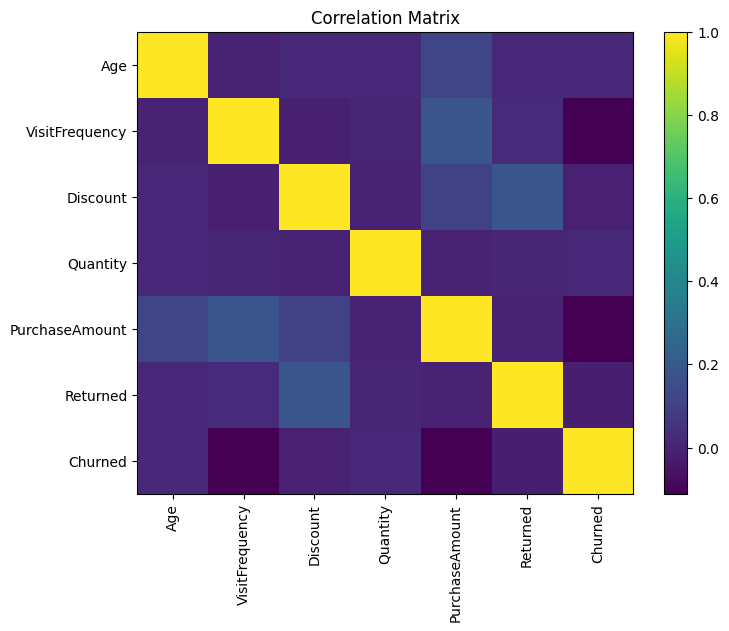


Pearson correlation between Discount and PurchaseAmount:
Correlation: 0.10643836203707462
p-value: 4.49207532334618e-14

Spearman correlation between Discount and PurchaseAmount:
Correlation: 0.12205133726110912
p-value: 4.694114804719492e-18


In [ ]:
# Correlation analysis


corr_matrix = df[["Age", "VisitFrequency", "Discount", "Quantity", "PurchaseAmount", "Returned", "Churned"]].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

pearson_corr, pearson_p = stats.pearsonr(df["Discount"], df["PurchaseAmount"])
spearman_corr, spearman_p = stats.spearmanr(df["Discount"], df["PurchaseAmount"])

print("\nPearson correlation between Discount and PurchaseAmount:")
print("Correlation:", pearson_corr)
print("p-value:", pearson_p)

print("\nSpearman correlation between Discount and PurchaseAmount:")
print("Correlation:", spearman_corr)
print("p-value:", spearman_p)


In [34]:
# Linear regression
# Predict PurchaseAmount


regression_df = pd.get_dummies(
    df[[
        "PurchaseAmount",
        "Age",
        "VisitFrequency",
        "Discount",
        "Quantity",
        "CustomerSegment",
        "Campaign"
    ]],
    columns=["CustomerSegment", "Campaign"],
    drop_first=True,
    dtype=int
)

# Define X and y
X = regression_df.drop("PurchaseAmount", axis=1)
y = regression_df["PurchaseAmount"]

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Remove missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Combine X and y to drop bad rows together
model_data = pd.concat([y, X], axis=1).dropna()

y = model_data["PurchaseAmount"]
X = model_data.drop("PurchaseAmount", axis=1)

# Convert to float for statsmodels
X = X.astype(float)
y = y.astype(float)

# Add intercept column
X = sm.add_constant(X)

# Fit linear regression model
linear_model = sm.OLS(y, X).fit()

print("\nLinear Regression Summary:")
print(linear_model.summary())






Linear Regression Summary:
                            OLS Regression Results                            
Dep. Variable:         PurchaseAmount   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     212.8
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          3.37e-311
Time:                        15:57:58   Log-Likelihood:                -28757.
No. Observations:                5000   AIC:                         5.753e+04
Df Residuals:                    4991   BIC:                         5.759e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

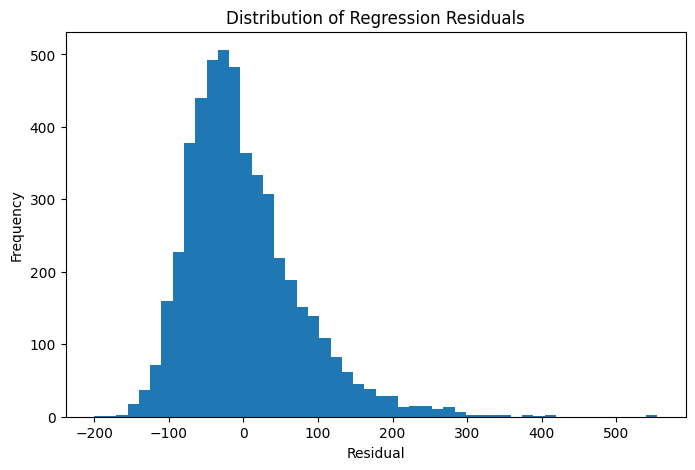

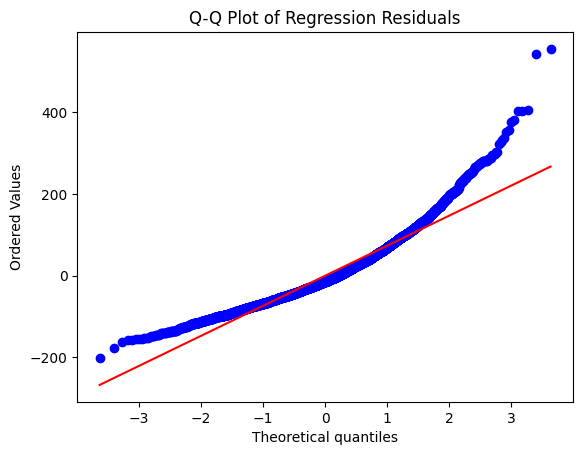

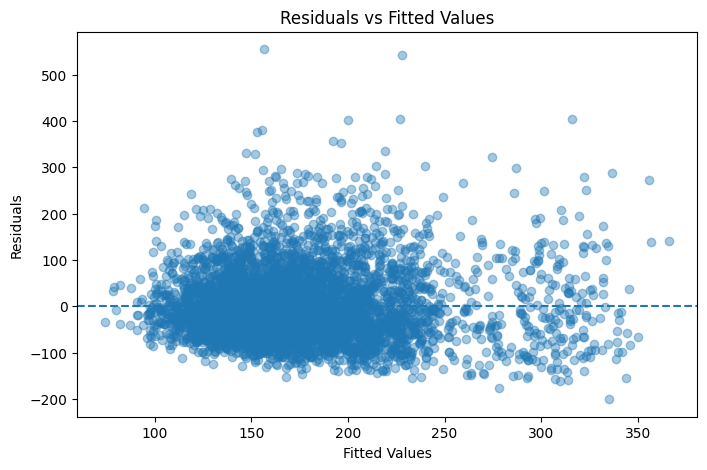


Variance Inflation Factor:
                   Feature        VIF
0                    const  28.267283
1                      Age   1.000884
2           VisitFrequency   1.001348
3                 Discount   1.001108
4                 Quantity   1.000318
5  CustomerSegment_Premium   1.266691
6  CustomerSegment_Regular   1.294107
7      CustomerSegment_VIP   1.085452
8      Campaign_Campaign_B   1.001000


In [35]:
# Regression assumptions


residuals = linear_model.resid
fitted_values = linear_model.fittedvalues

# Residual distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Regression Residuals")
plt.show()

# Residuals vs fitted values
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# VIF for multicollinearity
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("\nVariance Inflation Factor:")
print(vif_data)




Logistic Regression Evaluation:
Accuracy: 0.8208
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.6214668615984407

Confusion Matrix:
[[1026    0]
 [ 224    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1026
           1       0.00      0.00      0.00       224

    accuracy                           0.82      1250
   macro avg       0.41      0.50      0.45      1250
weighted avg       0.67      0.82      0.74      1250



d:\Statistics\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Statistics\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Statistics\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Statistics\venv\lib\site-packages\sklearn\metrics\_

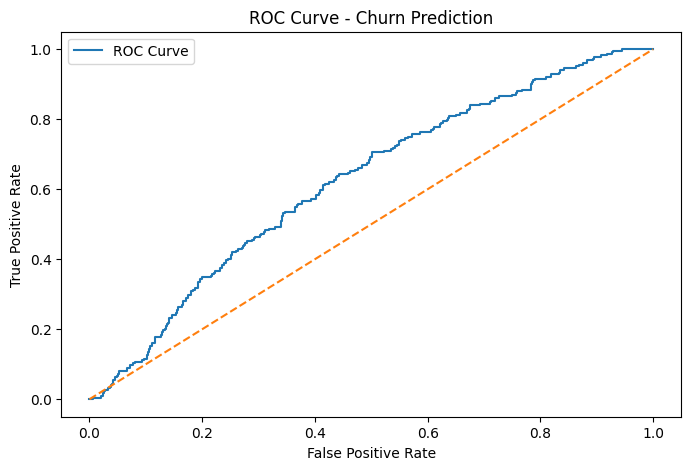

In [36]:
#Logistic regression
# Predict churn


logistic_df = pd.get_dummies(
    df[["Churned", "Age", "VisitFrequency", "Discount", "Quantity", "PurchaseAmount", "Returned", "CustomerSegment"]],
    columns=["CustomerSegment"],
    drop_first=True
)

X = logistic_df.drop("Churned", axis=1)
y = logistic_df["Churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [ ]:
#Logistic regression with statsmodels
# For p-values and odds ratios
# Target: Churned


logistic_df = pd.get_dummies(
    df[[
        "Churned",
        "Age",
        "VisitFrequency",
        "Discount",
        "Quantity",
        "PurchaseAmount",
        "Returned",
        "CustomerSegment"
    ]],
    columns=["CustomerSegment"],
    drop_first=True,
    dtype=int
)

# Define target and features
y_logit = logistic_df["Churned"]
X_logit = logistic_df.drop("Churned", axis=1)

# Convert to numeric
X_logit = X_logit.apply(pd.to_numeric, errors="coerce")
y_logit = pd.to_numeric(y_logit, errors="coerce")

# Replace infinite values with NaN
X_logit = X_logit.replace([np.inf, -np.inf], np.nan)
y_logit = y_logit.replace([np.inf, -np.inf], np.nan)

# Combine X and y, then remove missing values
logit_data = pd.concat([y_logit, X_logit], axis=1).dropna()

y_logit = logit_data["Churned"]
X_logit = logit_data.drop("Churned", axis=1)

# Convert to float
X_logit = X_logit.astype(float)
y_logit = y_logit.astype(float)

# Add constant/intercept
X_logit_sm = sm.add_constant(X_logit)

# Fit logistic regression model
logit_model = sm.Logit(y_logit, X_logit_sm).fit()

print("\nStatsmodels Logistic Regression Summary:")
print(logit_model.summary())

# Odds ratios
odds_ratios = np.exp(logit_model.params)

print("\nOdds Ratios:")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.448981
         Iterations 6

Statsmodels Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:                Churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4990
Method:                           MLE   Df Model:                            9
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                 0.04446
Time:                        16:02:19   Log-Likelihood:                -2244.9
converged:                       True   LL-Null:                       -2349.4
Covariance Type:            nonrobust   LLR p-value:                 4.440e-40
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.3866      

In [39]:
# A/B testing
# Campaign A vs Campaign B conversion


# Define conversion as PurchaseAmount > 150
df["Converted"] = np.where(df["PurchaseAmount"] > 150, 1, 0)

ab_summary = df.groupby("Campaign")["Converted"].agg(["sum", "count", "mean"])
print("\nA/B Test Conversion Summary:")
print(ab_summary)

conversions = ab_summary["sum"].values
sample_sizes = ab_summary["count"].values

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=sample_sizes,
    alternative="two-sided"
)

print("\nA/B Test for Conversion Rate:")
print("H0: Campaign A conversion rate = Campaign B conversion rate")
print("H1: Conversion rates are different")
print("z-statistic:", z_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Campaign conversion rates are significantly different.")
else:
    print("Conclusion: No significant difference in conversion rates.")




A/B Test Conversion Summary:
             sum  count      mean
Campaign                         
Campaign_A  1267   2523  0.502180
Campaign_B  1426   2477  0.575696

A/B Test for Conversion Rate:
H0: Campaign A conversion rate = Campaign B conversion rate
H1: Conversion rates are different
z-statistic: -5.21373865277688
p-value: 1.850721623982151e-07
Conclusion: Campaign conversion rates are significantly different.


In [40]:
# Business recommendations


segment_revenue = df.groupby("CustomerSegment")["PurchaseAmount"].agg(["count", "mean", "sum"])
campaign_revenue = df.groupby("Campaign")["PurchaseAmount"].agg(["count", "mean", "sum"])
churn_by_segment = df.groupby("CustomerSegment")["Churned"].mean()

print("\nRevenue by Customer Segment:")
print(segment_revenue)

print("\nRevenue by Campaign:")
print(campaign_revenue)

print("\nChurn Rate by Segment:")
print(churn_by_segment)

print("\nFinal Business Interpretation:")
print("""
1. Customer spending is right-skewed, meaning a small number of high-value customers generate large revenue.
2. Premium and VIP customers have significantly higher spending than other groups.
3. Campaign B can be evaluated using A/B testing for conversion improvement.
4. Visit frequency and customer segment are important factors in purchase amount and churn.
5. Churn prediction can help target risky customers with retention campaigns.
6. Outliers should not be blindly removed because they may represent valuable VIP customers.
""")


Revenue by Customer Segment:
                 count        mean        sum
CustomerSegment                              
New               1735  143.675660  249277.27
Premium           1036  213.733436  221427.84
Regular           1986  168.574129  334788.22
VIP                243  303.606461   73776.37

Revenue by Campaign:
            count        mean        sum
Campaign                                
Campaign_A   2523  167.714289  423143.15
Campaign_B   2477  184.144752  456126.55

Churn Rate by Segment:
CustomerSegment
New        0.261671
Premium    0.145753
Regular    0.135952
VIP        0.082305
Name: Churned, dtype: float64

Final Business Interpretation:

1. Customer spending is right-skewed, meaning a small number of high-value customers generate large revenue.
2. Premium and VIP customers have significantly higher spending than other groups.
3. Campaign B can be evaluated using A/B testing for conversion improvement.
4. Visit frequency and customer segment are important fa